# IT3212 Assignment 2 - Contour detection (15 points)

We extract boundaries of thresholded grayscale regions and compare them with multiscale LoG blobs.
The seven numbered sections correspond directly to the seven contour-detection subquestions in the PDF.

Run all cells in a fresh kernel. This notebook independently recomputes the blob baseline for comparison:
it does not require running another notebook or having its result CSVs available.
Figures are saved to `figures/assignment2/contour_detection/`; generated tables and configurations to
`results/assignment2/contour_detection/`.

## 1. Apply contour detection to the same image dataset

**Assignment point 1:** Apply contour detection to the same image dataset used for blob detection.

### Dataset, selection, and preparation

The user-supplied local dataset is `data/vehicle-type-detection/`. Record its original source/Blackboard
attribution before submission. Five folders label vehicle types rather than object boundaries. We use
the same 10 images from `detection_images.json` as the blob notebook. Two sorted filenames per class
form an exploratory sample, not a representative dataset evaluation.

Preparation is identical to the blob notebook: EXIF orientation, RGB conversion, aspect-preserving
resize to maximum side 512 without enlargement, and grayscale values divided by 255. Positions are
measured in processed-image pixels, with origin at the top left, x rightwards and y downwards.

In [1]:
from pathlib import Path
import json
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import hsv_to_rgb
from matplotlib.patches import Circle
from PIL import Image, ImageOps
from scipy.ndimage import gaussian_filter, gaussian_laplace, maximum_filter
from contourpy import contour_generator
from IPython.display import display, Markdown
import scipy
import contourpy

REPO_ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents]
                  if (p / "AGENTS.md").is_file() and (p / "notebooks").is_dir()), None)
if REPO_ROOT is None:
    raise FileNotFoundError("Run from within the IT3212 repository.")
DATA_DIR = REPO_ROOT / "data" / "vehicle-type-detection"
FIGURE_DIR = REPO_ROOT / "figures" / "assignment2" / "contour_detection"
RESULT_DIR = REPO_ROOT / "results" / "assignment2" / "contour_detection"
if not DATA_DIR.is_dir():
    raise FileNotFoundError(DATA_DIR)
for directory in [FIGURE_DIR, RESULT_DIR]:
    directory.mkdir(parents=True, exist_ok=True)
print(f"Python {sys.version.split()[0]}, NumPy {np.__version__}, SciPy {scipy.__version__}, ContourPy {contourpy.__version__}")
extensions = {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff"}
inventory = pd.DataFrame([
    dict(vehicle_class=d.name, images=sum(p.suffix.lower() in extensions for p in d.rglob("*") if p.is_file()))
    for d in sorted(DATA_DIR.iterdir()) if d.is_dir()
])
display(inventory)
print("Total images:", inventory.images.sum())
image_ids = json.loads((REPO_ROOT / "notebooks" / "assignment2" / "detection_images.json").read_text(encoding="utf-8"))
assert image_ids and len(image_ids) == len(set(image_ids))
for image_id in image_ids:
    if not (DATA_DIR / image_id).is_file():
        raise FileNotFoundError(DATA_DIR / image_id)

Python 3.13.7, NumPy 2.5.2, SciPy 1.18.1, ContourPy 1.3.3


,vehicle_class,images
0,hatchback,181
1,motorcycle,122
2,pickup,478
3,sedan,400
4,suv,129


Total images: 1310


In [2]:
MAX_SIDE = 512
records = {}
for image_id in image_ids:
    with Image.open(DATA_DIR / image_id) as source:
        rgb_image = ImageOps.exif_transpose(source).convert("RGB")
    original_width, original_height = rgb_image.size
    factor = min(1.0, MAX_SIDE / max(rgb_image.size))
    size = (max(1, round(original_width * factor)), max(1, round(original_height * factor)))
    if size != rgb_image.size:
        rgb_image = rgb_image.resize(size, Image.Resampling.LANCZOS)
    gray = np.asarray(rgb_image.convert("L"), dtype=np.float64) / 255.0
    assert gray.ndim == 2 and np.isfinite(gray).all() and 0 <= gray.min() <= gray.max() <= 1
    records[image_id] = dict(rgb=np.asarray(rgb_image), gray=gray,
                            original_width=original_width, original_height=original_height,
                            width=size[0], height=size[1],
                            scale_x=size[0] / original_width, scale_y=size[1] / original_height)
image_info = pd.DataFrame([
    dict(image=image_id, **{k: v for k, v in record.items() if k not in {"rgb", "gray"}})
    for image_id, record in records.items()
])
display(image_info)

,image,original_width,original_height,width,height,scale_x,scale_y
0,hatchback/PIC_0.jpg,136,173,136,173,1.000000,1.000000
1,hatchback/PIC_1.jpg,597,420,512,360,0.857621,0.857143
2,motorcycle/PIC_0.jpg,301,514,300,512,0.996678,0.996109
3,motorcycle/PIC_10.jpg,92,162,92,162,1.000000,1.000000
4,pickup/PIC_0.jpg,313,241,313,241,1.000000,1.000000
5,pickup/PIC_1.jpg,353,224,353,224,1.000000,1.000000
6,sedan/PIC_0.jpg,196,155,196,155,1.000000,1.000000
7,sedan/PIC_1.jpg,552,351,512,326,0.927536,0.928775
8,suv/PIC_0.jpg,509,338,509,338,1.000000,1.000000
9,suv/PIC_1.jpg,309,249,309,249,1.000000,1.000000


### Algorithm and baseline settings

1. Smooth grayscale intensities with a Gaussian filter, sigma 1 pixel.
2. Form a binary mask with `smoothed > 0.5`. This is a brightness threshold rather than the LoG response
   threshold in the blob notebook. Mask regions can contain parts of cars or their surroundings.
3. Trace the mask's 0.5 level using ContourPy's serial marching-squares contour engine. Boundaries are
   linearly interpolated between pixel centers, so coordinates may contain fractions of a pixel.
4. Retain closed loops with area at least 25 square pixels. Exclude open curves instead of artificially
   closing frame-intersecting boundaries. Record how many paths were discarded.

All closed loops are candidates, including boundaries around holes. They are counted separately; this
is not an external-contours-only policy and no object hierarchy is inferred. Areas describe individual
loops, not net foreground area. Summing nested loop areas would double-count enclosed regions.

This threshold-based method preserves irregular outlines, but requires suitable contrast. A single
global brightness threshold is an interpretable baseline, not a vehicle-segmentation model.

In [3]:
CONTOUR_COLUMNS = ["contour_id", "area_px2", "perimeter_px", "centroid_x_px", "centroid_y_px", "n_vertices"]

def polygon_statistics(vertices):
    """Area, closed perimeter, and area-weighted centroid for an ordered closed polygon."""
    vertices = np.asarray(vertices, dtype=np.float64)
    if not np.allclose(vertices[0], vertices[-1]):
        raise ValueError("An open curve has no enclosed polygon area.")
    a, b = vertices[:-1], vertices[1:]
    cross = a[:, 0] * b[:, 1] - b[:, 0] * a[:, 1]
    signed_area = cross.sum() / 2
    if abs(signed_area) <= 1e-12:
        return 0.0, np.linalg.norm(b - a, axis=1).sum(), np.nan, np.nan
    centroid = ((a + b) * cross[:, None]).sum(axis=0) / (6 * signed_area)
    return abs(signed_area), np.linalg.norm(b - a, axis=1).sum(), *centroid

CONTOUR_BASELINE = dict(threshold=0.5, smooth_sigma=1.0, min_area=25.0)

def detect_contours(gray, threshold=0.5, smooth_sigma=1.0, min_area=25.0):
    """Threshold, trace all mask boundaries, retain measurable closed polygons."""
    gray = np.asarray(gray, dtype=np.float64)
    if gray.ndim != 2 or min(gray.shape) < 2 or not np.isfinite(gray).all() or gray.min() < 0 or gray.max() > 1:
        raise ValueError("Expected a finite grayscale image in [0, 1], at least 2x2.")
    if not (0 < threshold < 1 and smooth_sigma >= 0 and min_area >= 0):
        raise ValueError("Invalid contour parameters.")
    smoothed = gaussian_filter(gray, smooth_sigma, mode="reflect") if smooth_sigma else gray.copy()
    mask = smoothed > threshold
    # A constant mask has no foreground/background transitions.
    paths = (contour_generator(z=mask.astype(float), name="serial", line_type="Separate").lines(0.5)
             if mask.any() and not mask.all() else [])
    kept, rows = [], []
    n_open = n_small = 0
    for vertices in paths:
        if len(vertices) < 4 or not np.allclose(vertices[0], vertices[-1]):
            n_open += 1
            continue
        area, perimeter, cx, cy = polygon_statistics(vertices)
        if area <= 1e-12 or area < min_area:
            n_small += 1
            continue
        kept.append(vertices)
        rows.append(dict(contour_id=len(kept), area_px2=area, perimeter_px=perimeter,
                         centroid_x_px=cx, centroid_y_px=cy, n_vertices=len(vertices) - 1))
    statistics = pd.DataFrame(rows, columns=CONTOUR_COLUMNS)
    assert len(paths) == len(kept) + n_open + n_small
    return dict(smoothed=smoothed, mask=mask, contours=kept, statistics=statistics,
                raw_paths=len(paths), excluded_open=n_open, excluded_small=n_small)

baseline_results = {image_id: detect_contours(record["gray"], **CONTOUR_BASELINE)
                    for image_id, record in records.items()}
display(pd.Series(CONTOUR_BASELINE, name="baseline value"))

threshold        0.5
smooth_sigma     1.0
min_area        25.0
Name: baseline value, dtype: float64

### Checks with known geometry

A square verifies polygon measurements; a binary rectangle verifies boundary extraction. A region
crossing the frame should produce an open path which is excluded. A ring verifies that outer and hole
boundaries are separate loops. A constant image verifies the zero-detection case.
These checks verify the implementation; they do not measure accuracy on vehicles.

In [4]:
square = np.array([[0, 0], [10, 0], [10, 10], [0, 10], [0, 0]], dtype=float)
a, p, cx, cy = polygon_statistics(square)
assert np.allclose([a, p, cx, cy], [100, 40, 5, 5])
rectangle = np.zeros((64, 64))
rectangle[10:30, 10:30] = 1
check = detect_contours(rectangle, smooth_sigma=0, min_area=0)
assert len(check["contours"]) == 1
assert abs(check["statistics"].iloc[0].area_px2 - 400) < 1
assert np.allclose(check["statistics"].iloc[0][["centroid_x_px", "centroid_y_px"]].astype(float), [19.5, 19.5])
rectangle[:30, 10:30] = 1
border = detect_contours(rectangle, smooth_sigma=0, min_area=0)
assert border["excluded_open"] == 1 and not border["contours"]
ring = np.zeros((64, 64))
ring[10:50, 10:50] = 1
ring[20:40, 20:40] = 0
assert len(detect_contours(ring, smooth_sigma=0, min_area=0)["contours"]) == 2
assert not detect_contours(np.zeros((64, 64)))["contours"]
print("Passed: polygon measurements, extracted rectangle, border handling, hole loops, and empty image.")

Passed: polygon measurements, extracted rectangle, border handling, hole loops, and empty image.


## 2. Visualize each contour in a different color

**Assignment point 2:** Visualize detected contours on the original images, using a different color for each.

Contours have deterministic colors generated from distinct hues, with IDs matching point 3's table.
The first panel shows the prepared original, the second its binary mask, and the third retained contours.
Paths discarded as open or too small are not counted or drawn as retained contours. Colors are assigned
within each image and do not indicate vehicle class or correspondence between images.

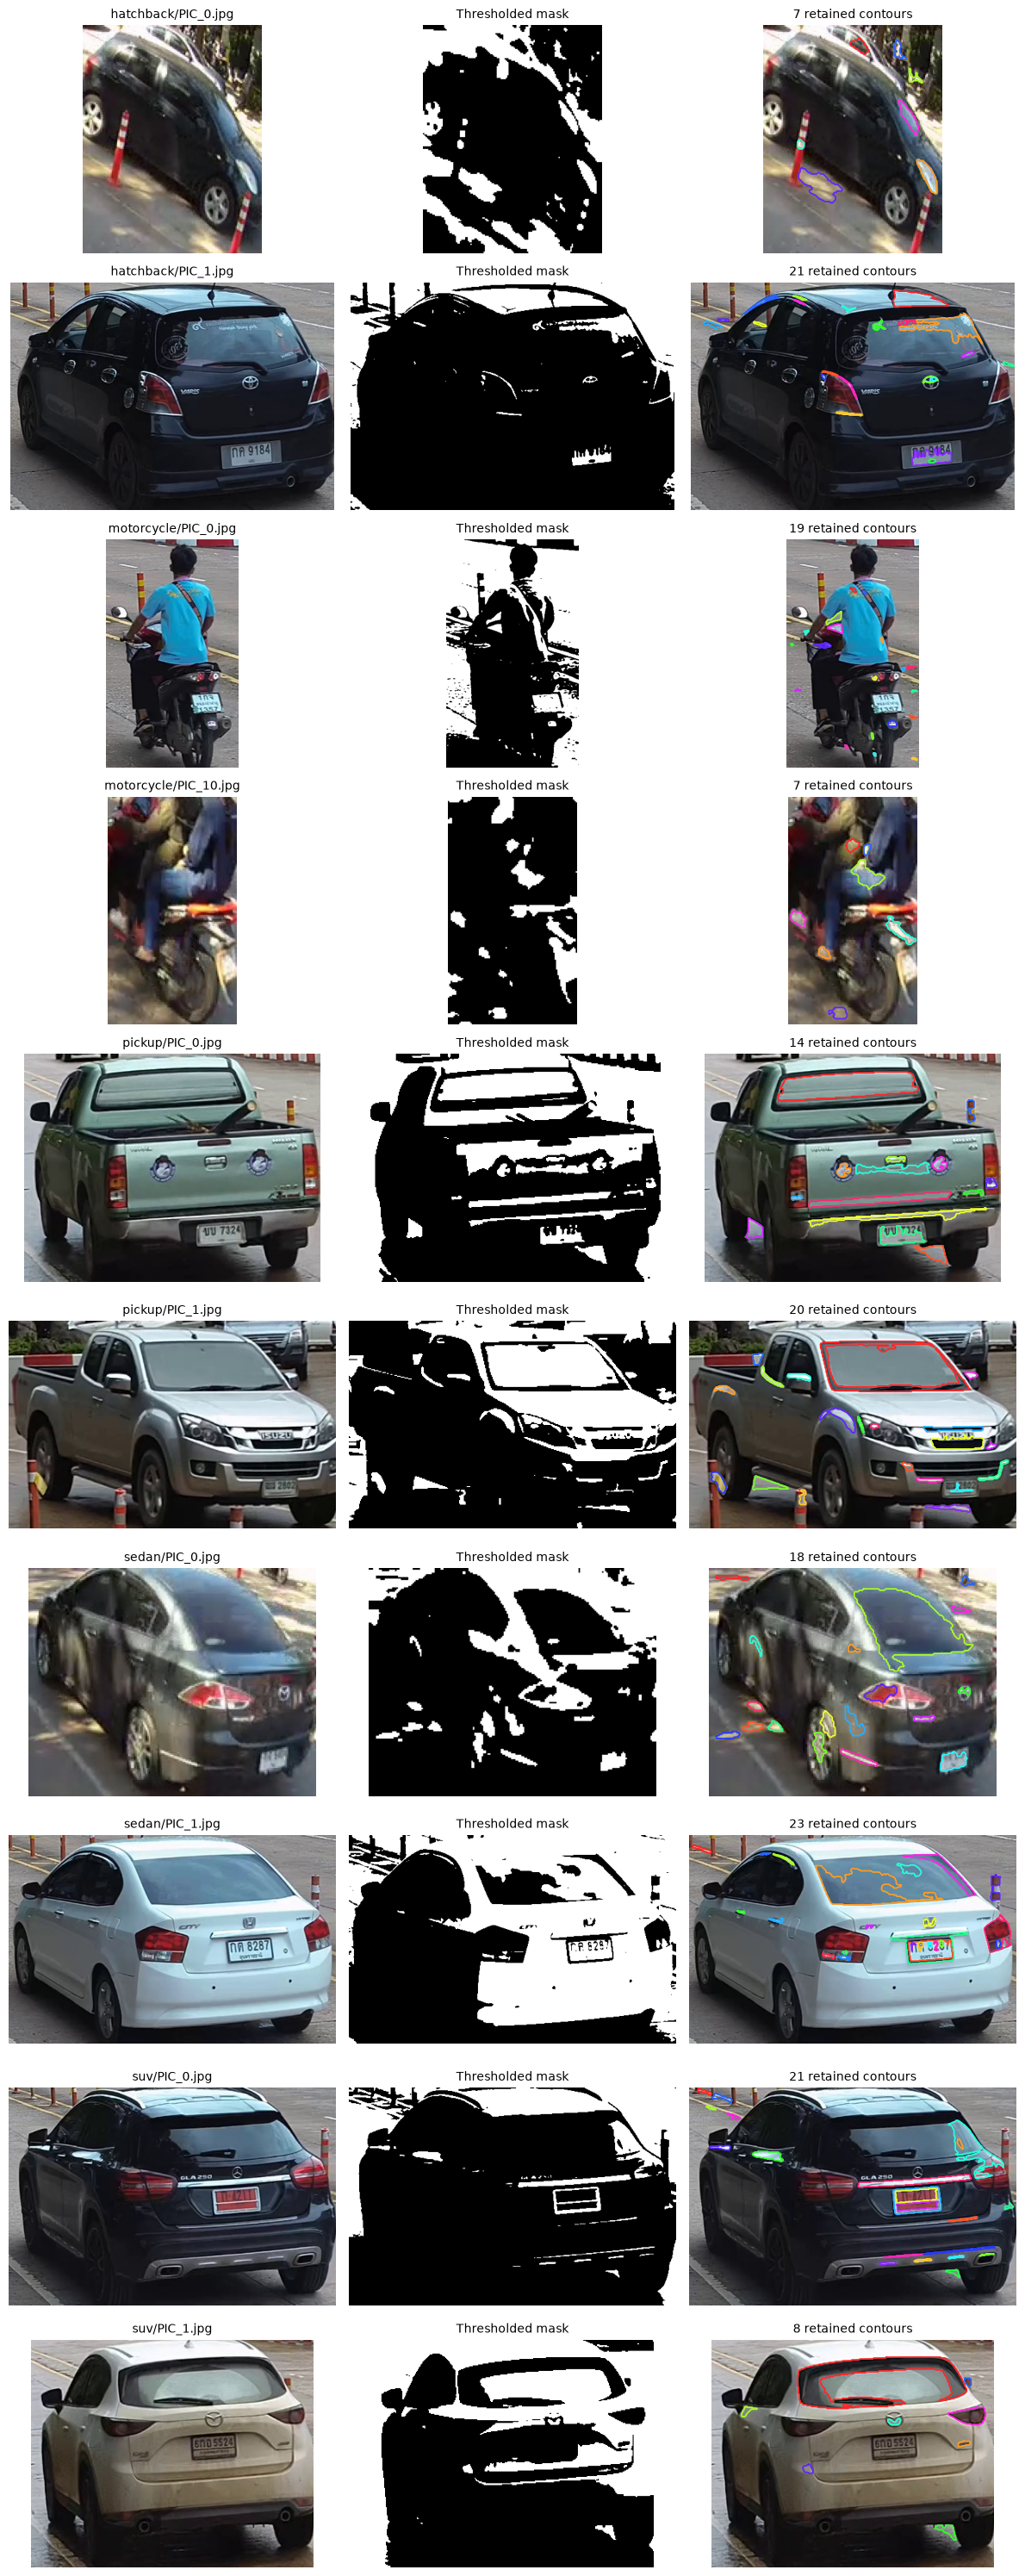

In [5]:
def draw_contours(ax, record, result, title, annotate=False):
    ax.imshow(record["rgb"])
    for vertices, row in zip(result["contours"], result["statistics"].itertuples(index=False)):
        color = hsv_to_rgb([((row.contour_id - 1) * 0.61803398875) % 1, 0.85, 1.0])
        ax.plot(vertices[:, 0], vertices[:, 1], color=color, linewidth=1.25)
        if annotate:
            # Put the ID on the boundary; the polygon centroid can lie outside concave polygons.
            x, y = vertices[0]
            ax.text(x, y, str(row.contour_id), fontsize=7, color=color,
                    bbox=dict(facecolor="black", alpha=0.65, edgecolor="none", pad=0.5))
    ax.set_title(title, fontsize=10)
    ax.set_xlim(-0.5, record["width"] - 0.5)
    ax.set_ylim(record["height"] - 0.5, -0.5)
    ax.axis("off")

fig, axes = plt.subplots(len(records), 3, figsize=(12, 3 * len(records)), squeeze=False)
for row, (image_id, record) in zip(axes, records.items()):
    result = baseline_results[image_id]
    row[0].imshow(record["rgb"])
    row[0].set_title(image_id, fontsize=10)
    row[0].axis("off")
    row[1].imshow(result["mask"], cmap="gray", vmin=0, vmax=1)
    row[1].set_title("Thresholded mask", fontsize=10)
    row[1].axis("off")
    draw_contours(row[2], record, result, f"{len(result['contours'])} retained contours")
fig.tight_layout()
fig.savefig(FIGURE_DIR / "01_baseline_contours.png", dpi=110)
plt.show()
plt.close(fig)

for image_id, record in records.items():
    result = baseline_results[image_id]
    fig, axes = plt.subplots(1, 3, figsize=(12, 5))
    axes[0].imshow(record["rgb"])
    axes[0].set_title("Original (prepared size)")
    axes[0].axis("off")
    axes[1].imshow(result["mask"], cmap="gray", vmin=0, vmax=1)
    axes[1].set_title("Thresholded mask")
    axes[1].axis("off")
    draw_contours(axes[2], record, result, image_id, annotate=True)
    fig.tight_layout()
    fig.savefig(FIGURE_DIR / (image_id.replace("/", "_").rsplit(".", 1)[0] + "_contours.png"), dpi=140)
    plt.close(fig)

## 3. Calculate and display contour counts, areas, and perimeters

**Assignment point 3:** Report statistics per image, including the number of contours, area, and perimeter.

For ordered vertices, area uses the shoelace formula and perimeter sums segment lengths:
$A=\frac{1}{2}|\sum_i(x_i y_{i+1}-x_{i+1}y_i)|$ and
$P=\sum_i\sqrt{(x_{i+1}-x_i)^2+(y_{i+1}-y_i)^2}$.
Measurements use processed pixels and square pixels. These are individual closed-loop geometric areas,
not vehicle sizes. Nested loops are counted independently. Open paths have no unambiguous enclosed area
and are excluded rather than assigned a fabricated one. Counts include zero-detection images; empty
means remain undefined.

In [6]:
def summarize_contours(results):
    rows = []
    for image_id, result in results.items():
        table = result["statistics"]
        rows.append(dict(image=image_id, raw_paths=result["raw_paths"],
                         excluded_open=result["excluded_open"], excluded_small=result["excluded_small"],
                         n_contours=len(table), mean_area_px2=table.area_px2.mean(),
                         mean_perimeter_px=table.perimeter_px.mean()))
    return pd.DataFrame(rows)

summary = summarize_contours(baseline_results)
detail_frames = []
for image_id, result in baseline_results.items():
    detail = result["statistics"].copy()
    detail.insert(0, "image", image_id)
    detail_frames.append(detail)
contour_details = pd.concat(detail_frames, ignore_index=True)
display(summary.round(2))
with pd.option_context("display.max_rows", None):
    display(contour_details.round(2))
summary.to_csv(RESULT_DIR / "baseline_summary.csv", index=False)
contour_details.to_csv(RESULT_DIR / "baseline_contours.csv", index=False)
image_info.to_csv(RESULT_DIR / "image_preparation.csv", index=False)
(RESULT_DIR / "baseline_config.json").write_text(json.dumps(
    dict(parameters=CONTOUR_BASELINE, max_side=MAX_SIDE, images=image_ids), indent=2), encoding="utf-8")
(RESULT_DIR / "baseline_vertices.json").write_text(json.dumps({
    image_id: [vertices.tolist() for vertices in result["contours"]]
    for image_id, result in baseline_results.items()
}), encoding="utf-8")

,image,raw_paths,excluded_open,excluded_small,n_contours,mean_area_px2,mean_perimeter_px
0,hatchback/PIC_0.jpg,47,11,29,7,139.50,55.03
1,hatchback/PIC_1.jpg,99,19,59,21,289.93,98.32
2,motorcycle/PIC_0.jpg,204,29,156,19,93.13,45.98
3,motorcycle/PIC_10.jpg,23,10,6,7,92.07,42.77
4,pickup/PIC_0.jpg,49,15,20,14,521.21,140.37
5,pickup/PIC_1.jpg,80,23,37,20,224.35,105.59
6,sedan/PIC_0.jpg,46,13,15,18,197.78,52.77
7,sedan/PIC_1.jpg,106,26,57,23,649.59,114.83
8,suv/PIC_0.jpg,78,16,41,21,479.79,125.92
9,suv/PIC_1.jpg,28,4,16,8,677.62,135.84


,image,contour_id,area_px2,perimeter_px,centroid_x_px,centroid_y_px,n_vertices
0,hatchback/PIC_0.jpg,1,89.5,40.28,72.98,15.30,52
1,hatchback/PIC_0.jpg,2,59.5,44.04,102.32,18.75,54
2,hatchback/PIC_0.jpg,3,40.5,43.80,114.28,39.47,52
3,hatchback/PIC_0.jpg,4,150.5,65.60,110.32,69.62,82
4,hatchback/PIC_0.jpg,5,28.5,19.90,27.90,90.17,24
5,hatchback/PIC_0.jpg,6,179.5,67.36,124.92,114.01,82
6,hatchback/PIC_0.jpg,7,428.5,104.23,42.41,121.34,130
7,hatchback/PIC_1.jpg,1,1498.5,216.08,354.36,26.95,236
8,hatchback/PIC_1.jpg,2,170.5,175.58,113.19,30.75,216
9,hatchback/PIC_1.jpg,3,39.5,48.63,172.38,24.10,58


267495

## 4. Compare blob detection and contour detection

**Assignment point 4:** Compare results of blob and contour detection on the chosen dataset.

Recompute the exact LoG baseline implemented in `05_blob_detection.ipynb` on the same prepared images.
The helper functions below are repeated explicitly so this notebook runs independently; keep their
algorithm and parameters synchronized with that notebook when changing the comparison.
LoG uses no additional smoothing and finds bright/dark extrema at sigma 4-16. Contours use Gaussian
smoothing sigma 1 and a brightness threshold 0.5. These method-specific thresholds measure different
quantities and cannot be equated numerically.

A blob's circle area estimates its filter scale. A contour's area measures an enclosed polygon. A
single blob need not correspond to a single contour. We compare geometry and behavior, not agreement
with unprovided ground truth or vehicle counts.

,image,n_contours,mean_area_px2,mean_perimeter_px,n_blobs,mean_blob_radius_px,mean_blob_circle_area_px2
0,hatchback/PIC_0.jpg,7,139.50,55.03,33,7.22,217.11
1,hatchback/PIC_1.jpg,21,289.93,98.32,85,7.70,235.45
2,motorcycle/PIC_0.jpg,19,93.13,45.98,83,7.23,205.59
3,motorcycle/PIC_10.jpg,7,92.07,42.77,19,6.10,121.39
4,pickup/PIC_0.jpg,14,521.21,140.37,110,6.96,177.05
5,pickup/PIC_1.jpg,20,224.35,105.59,106,6.74,165.42
6,sedan/PIC_0.jpg,18,197.78,52.77,27,8.14,255.54
7,sedan/PIC_1.jpg,23,649.59,114.83,70,9.68,391.35
8,suv/PIC_0.jpg,21,479.79,125.92,107,7.12,193.98
9,suv/PIC_1.jpg,8,677.62,135.84,55,8.21,257.92


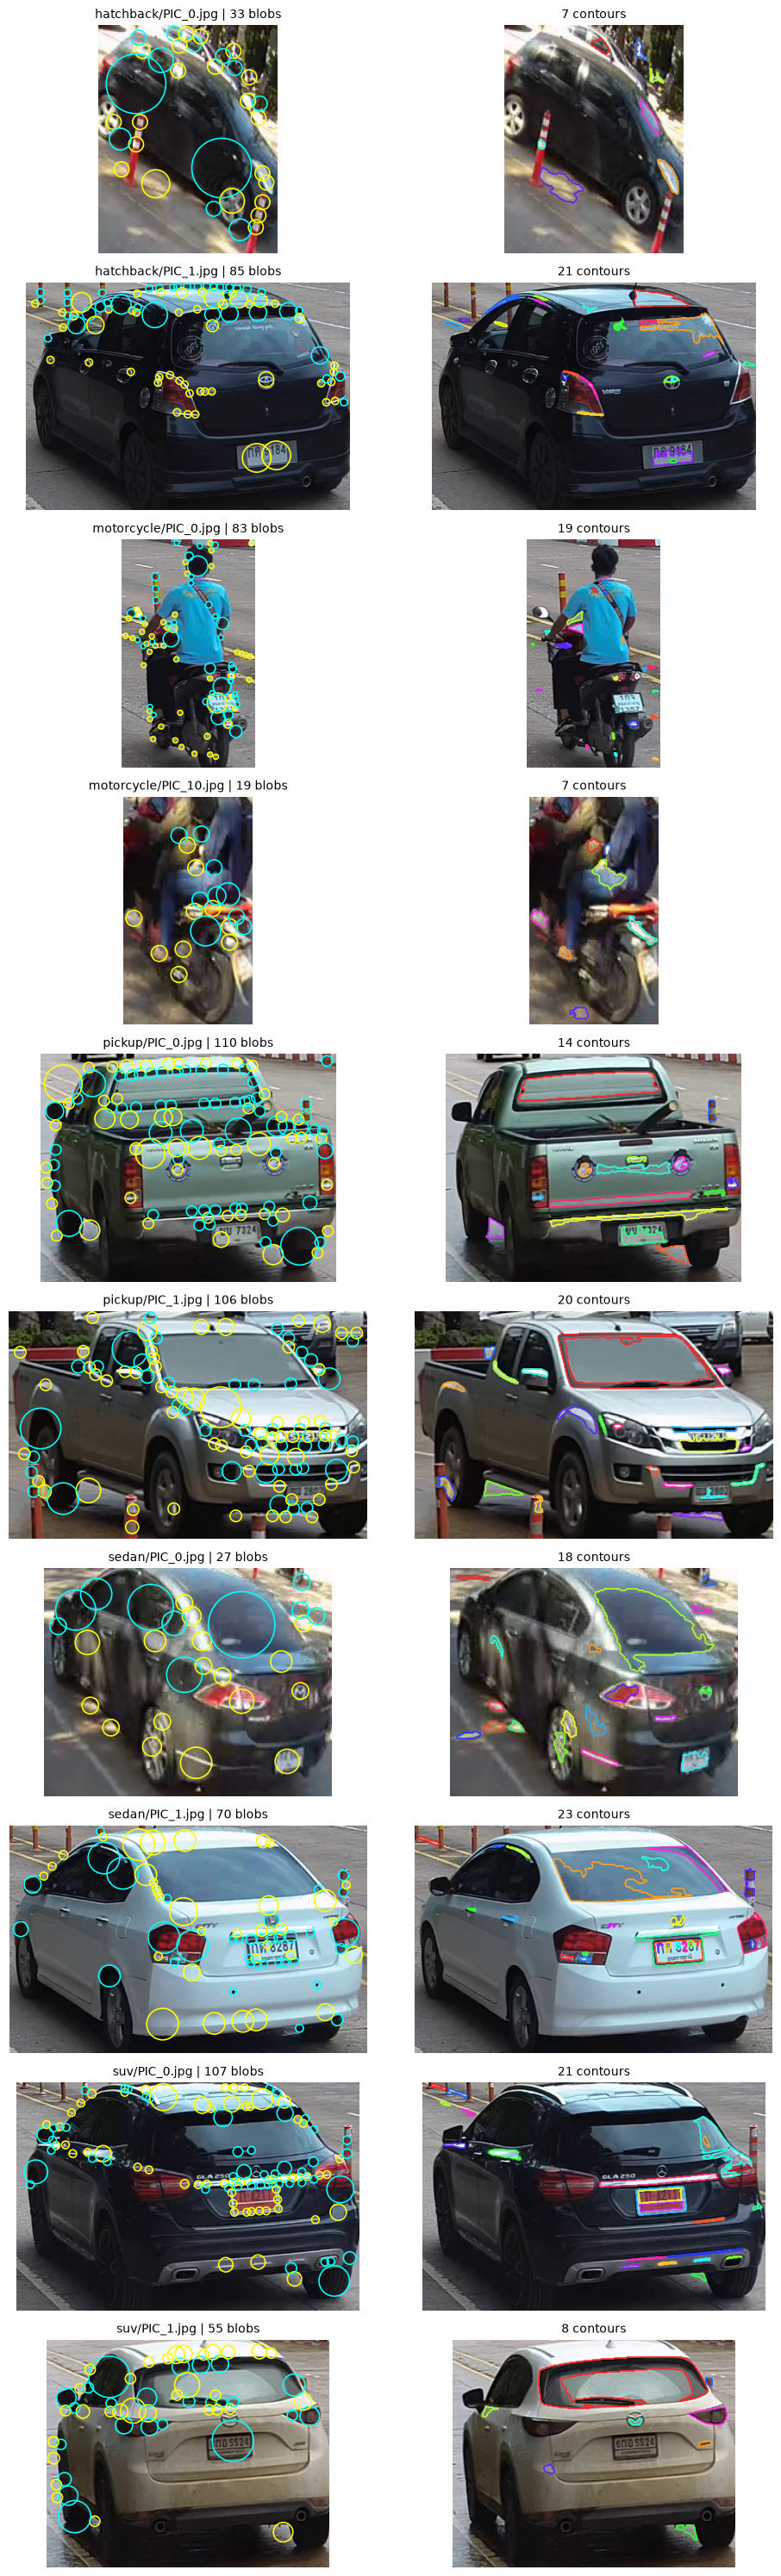

This run retains **695 blobs** and **158 closed contours** on the same 10 images. These totals count different features and do not measure relative accuracy.

In [7]:
def circle_overlap_fraction(a, b):
    """Intersection area divided by smaller circle area; circles are (y, x, radius)."""
    y1, x1, r1 = a
    y2, x2, r2 = b
    distance = np.hypot(y1 - y2, x1 - x2)
    if distance >= r1 + r2:
        return 0.0
    if distance <= abs(r1 - r2):
        return 1.0
    angle1 = np.arccos(np.clip((distance**2 + r1**2 - r2**2) / (2 * distance * r1), -1, 1))
    angle2 = np.arccos(np.clip((distance**2 + r2**2 - r1**2) / (2 * distance * r2), -1, 1))
    product = (-distance + r1 + r2) * (distance + r1 - r2) * (distance - r1 + r2) * (distance + r1 + r2)
    area = r1**2 * angle1 + r2**2 * angle2 - 0.5 * np.sqrt(max(0.0, product))
    return area / (np.pi * min(r1, r2)**2)

def overlaps_any(circle, previous, threshold):
    """Vectorized circle-overlap calculation with the same smaller-area suppression rule."""
    if not previous:
        return False
    y, x, radius = circle
    prior = np.asarray(previous)
    distances = np.hypot(prior[:, 0] - y, prior[:, 1] - x)
    radii = prior[:, 2]
    intersect = distances < radius + radii
    if not intersect.any():
        return False
    distances, radii = distances[intersect], radii[intersect]
    contained = distances <= np.abs(radius - radii)
    if threshold < 1 and contained.any():
        return True
    distances, radii = distances[~contained], radii[~contained]
    if not len(distances):
        return False
    angle1 = np.arccos(np.clip((distances**2 + radius**2 - radii**2) / (2 * distances * radius), -1, 1))
    angle2 = np.arccos(np.clip((distances**2 + radii**2 - radius**2) / (2 * distances * radii), -1, 1))
    product = (-distances + radius + radii) * (distances + radius - radii) * (distances - radius + radii) * (distances + radius + radii)
    areas = radius**2 * angle1 + radii**2 * angle2 - 0.5 * np.sqrt(np.maximum(0.0, product))
    return bool((areas / (np.pi * np.minimum(radius, radii)**2) > threshold).any())

BLOB_COLUMNS = ["x_px", "y_px", "sigma_px", "radius_px", "diameter_px",
                "circle_area_px2", "response", "polarity"]

def detect_blobs(gray, min_sigma=4.0, max_sigma=16.0, num_sigma=12,
                 threshold=0.15, overlap=0.5, pre_smooth=0.0, response_cache=None):
    """Return bright and dark LoG blobs in processed-image coordinates."""
    gray = np.asarray(gray, dtype=np.float64)
    if gray.ndim != 2 or not np.isfinite(gray).all() or gray.min() < 0 or gray.max() > 1:
        raise ValueError("Expected a finite 2D grayscale image in [0, 1].")
    if not (0 < min_sigma < max_sigma and num_sigma >= 3 and threshold > 0
            and 0 <= overlap <= 1 and pre_smooth >= 0):
        raise ValueError("Invalid detector parameters.")
    # A cache belongs to one image only; threshold/overlap changes reuse its scale responses.
    key = (min_sigma, max_sigma, num_sigma, pre_smooth)
    if response_cache is not None and key in response_cache:
        sigmas, signed = response_cache[key]
    else:
        prepared = gaussian_filter(gray, pre_smooth, mode="reflect") if pre_smooth else gray
        sigmas = np.geomspace(min_sigma, max_sigma, num_sigma)
        signed = np.stack([-s**2 * gaussian_laplace(prepared, s, mode="reflect") for s in sigmas])
        if response_cache is not None:
            response_cache[key] = (sigmas, signed)
    strength = np.abs(signed)
    peaks = (strength == maximum_filter(strength, size=(3, 3, 3), mode="nearest")) & (strength > threshold)
    scale_indices, ys, xs = np.nonzero(peaks)
    scores = strength[scale_indices, ys, xs]
    kept_circles, rows = [], []
    height, width = gray.shape
    for index in np.argsort(-scores, kind="stable"):
        scale_index, y, x = scale_indices[index], ys[index], xs[index]
        sigma = sigmas[scale_index]
        radius = np.sqrt(2) * sigma
        if x - radius < 0 or y - radius < 0 or x + radius > width - 1 or y + radius > height - 1:
            continue
        circle = (float(y), float(x), radius)
        if overlaps_any(circle, kept_circles, overlap):
            continue
        kept_circles.append(circle)
        rows.append(dict(x_px=float(x), y_px=float(y), sigma_px=sigma, radius_px=radius,
                         diameter_px=2 * radius, circle_area_px2=np.pi * radius**2,
                         response=float(scores[index]),
                         polarity="bright" if signed[scale_index, y, x] > 0 else "dark"))
    return pd.DataFrame(rows, columns=BLOB_COLUMNS)


BLOB_BASELINE = dict(min_sigma=4.0, max_sigma=16.0, num_sigma=12,
                     threshold=0.15, overlap=0.5, pre_smooth=0.0)
blob_results = {image_id: detect_blobs(record["gray"], **BLOB_BASELINE)
                for image_id, record in records.items()}
comparison = summary[["image", "n_contours", "mean_area_px2", "mean_perimeter_px"]].copy()
comparison["n_blobs"] = [len(blob_results[i]) for i in comparison.image]
comparison["mean_blob_radius_px"] = [blob_results[i].radius_px.mean() for i in comparison.image]
comparison["mean_blob_circle_area_px2"] = [blob_results[i].circle_area_px2.mean() for i in comparison.image]
display(comparison.round(2))
comparison.to_csv(RESULT_DIR / "blob_contour_comparison.csv", index=False)
(RESULT_DIR / "blob_comparison_config.json").write_text(json.dumps(BLOB_BASELINE, indent=2), encoding="utf-8")

fig, axes = plt.subplots(len(records), 2, figsize=(10, 3 * len(records)), squeeze=False)
for row, (image_id, record) in zip(axes, records.items()):
    blobs = blob_results[image_id]
    row[0].imshow(record["rgb"])
    for b in blobs.itertuples(index=False):
        row[0].add_patch(Circle((b.x_px, b.y_px), b.radius_px, fill=False,
                               color="yellow" if b.polarity == "bright" else "cyan", linewidth=1.2))
    row[0].set_title(f"{image_id} | {len(blobs)} blobs", fontsize=10)
    row[0].axis("off")
    draw_contours(row[1], record, baseline_results[image_id],
                  f"{len(baseline_results[image_id]['contours'])} contours")
fig.tight_layout()
fig.savefig(FIGURE_DIR / "02_blob_contour_comparison.png", dpi=110)
plt.show()
plt.close(fig)
display(Markdown(f"This run retains **{int(comparison.n_blobs.sum())} blobs** and "
                 f"**{int(comparison.n_contours.sum())} closed contours** on the same {len(records)} images. "
                 "These totals count different features and do not measure relative accuracy."))

### Observations on the selected images

The baseline retains 158 closed contours (7-23 per image) compared with 695 LoG blobs. In
`pickup/PIC_0.jpg`, the 14 contours follow elongated window and bumper regions, badges, and parts
of the plate. The 110 blobs give many circular responses along the trim and other contrast details.
Contours provide the actual irregular outlines of the selected mask regions; circles summarize local
contrast at particular scales. Neither representation coincides with a complete pickup outline.

In `sedan/PIC_0.jpg`, a retained contour follows a large window region and smaller contours follow
lamp, wheel, plate, and background patches, while LoG places circles over compact contrasting parts.
In `motorcycle/PIC_0.jpg`, contour regions include clothing and vehicle details rather than isolating
the motorcycle from its rider. These examples show why geometric feature detection does not by
itself identify semantic objects.

Across the sample, 166 open paths and 436 smaller/degenerate closed paths are excluded by the baseline.
A low count can therefore reflect the threshold and retention rules, not simply an image with few
objects. Frame-crossing regions are excluded, and the foreground and background can merge in the
binary mask. The baseline does not reliably recover complete vehicle silhouettes. The counts
compare different feature definitions and cannot establish that either technique is more accurate.


## 5. Discuss advantages and limitations of each technique

**Assignment point 5:** Discuss the advantages and limitations of blob and contour detection.

| Aspect | LoG blobs | Threshold-based contours |
|---|---|---|
| Representation | Center and approximate circular radius | Ordered boundary vertices with area and perimeter |
| Strength | Compact contrast features at multiple scales | Irregular closed shapes and geometric measurements |
| Sensitivity | Response threshold, scale range, overlapping responses | Brightness threshold, smoothing, boundary closure |
| Typical failure | Background/edge responses and several blobs per object | Fragmentation, merged regions, missing frame-crossing boundaries |
| Holes and shape | No explicit boundary or hole representation | Inner and outer loops retained separately; no net-area hierarchy |

LoG captures local contrast without specifying a single foreground brightness class, but a circle may
poorly represent elongated objects. Contours follow boundaries of the chosen mask and support shape
analysis, but the mask must first separate the desired regions. Neither method recognizes a vehicle
class. Shadows, reflections, perspective, and background clutter affect both methods.

Without annotated regions or boundaries, we assess visual plausibility and sensitivity rather than
precision/recall. Pixel size also varies between photographs, so region measurements are not physical
vehicle dimensions. The ten filename-selected examples do not establish performance on all images.

## 6. Analyze parameter effects: thresholds and filter sizes

**Assignment point 6:** Analyze how different parameters, such as threshold values and filter sizes,
affect detection results.

Change one baseline parameter at a time on every selected image: brightness threshold 0.35/0.65,
Gaussian sigma 0/2, or minimum area 100 instead of 25. Sigma controls the smoothing filter's spatial
extent. All other settings and input images remain fixed. A larger minimum area changes retention,
not boundary tracing. Changing brightness thresholds can split, merge, create, or remove regions;
there is no general monotonic relationship between threshold and contour count.

setting,baseline,lower threshold,higher threshold,no smoothing,stronger smoothing,larger minimum area
image,,,,,,
hatchback/PIC_0.jpg,7,9,6,11,4,3
hatchback/PIC_1.jpg,21,27,16,25,8,9
motorcycle/PIC_0.jpg,19,26,14,33,12,4
motorcycle/PIC_10.jpg,7,6,4,8,6,2
pickup/PIC_0.jpg,14,14,11,27,13,10
pickup/PIC_1.jpg,20,23,16,28,14,10
sedan/PIC_0.jpg,18,12,5,18,10,5
sedan/PIC_1.jpg,23,22,15,34,13,9
suv/PIC_0.jpg,21,33,17,33,11,10


,total_contours,excluded_open,excluded_small,mean_area_px2,mean_perimeter_px
setting,,,,,
baseline,158,166,436,349.75,95.07
lower threshold,182,115,375,343.47,93.17
higher threshold,109,135,381,278.01,88.67
no smoothing,230,319,1933,342.65,101.85
stronger smoothing,96,110,72,328.60,88.14
larger minimum area,65,166,529,773.42,172.07


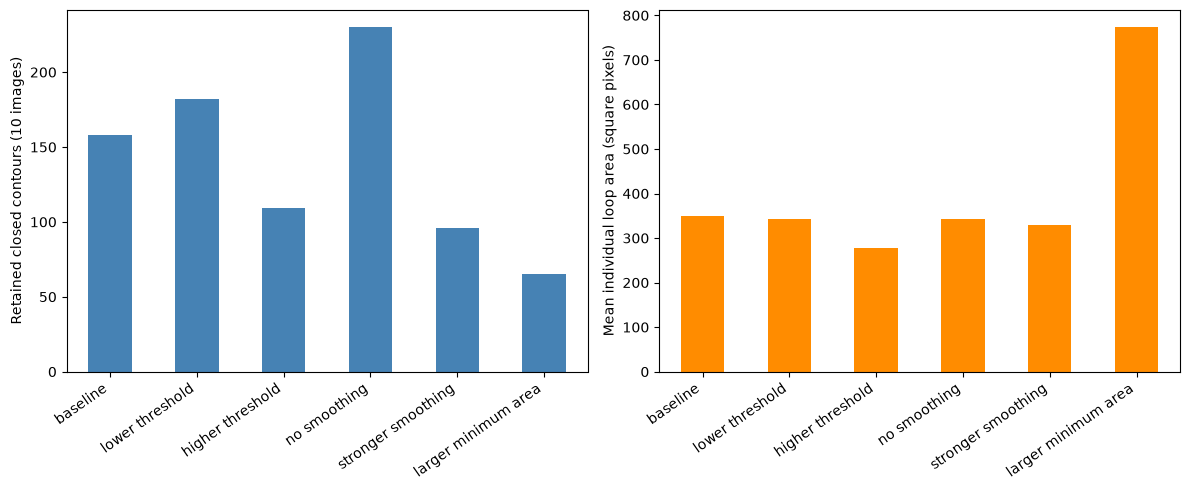

In [8]:
CONFIGS = {
    "baseline": CONTOUR_BASELINE,
    "lower threshold": {**CONTOUR_BASELINE, "threshold": 0.35},
    "higher threshold": {**CONTOUR_BASELINE, "threshold": 0.65},
    "no smoothing": {**CONTOUR_BASELINE, "smooth_sigma": 0.0},
    "stronger smoothing": {**CONTOUR_BASELINE, "smooth_sigma": 2.0},
    "larger minimum area": {**CONTOUR_BASELINE, "min_area": 100.0},
}
experiment_results = {"baseline": baseline_results}
for name, config in CONFIGS.items():
    if name != "baseline":
        experiment_results[name] = {
            image_id: detect_contours(record["gray"], **config)
            for image_id, record in records.items()
        }
experiments = pd.concat([summarize_contours(results).assign(setting=name)
                         for name, results in experiment_results.items()], ignore_index=True)
counts = experiments.pivot(index="image", columns="setting", values="n_contours").reindex(columns=CONFIGS)
display(counts)
aggregate = pd.DataFrame([
    dict(setting=name, total_contours=sum(len(r["contours"]) for r in results.values()),
         excluded_open=sum(r["excluded_open"] for r in results.values()),
         excluded_small=sum(r["excluded_small"] for r in results.values()),
         mean_area_px2=pd.concat([r["statistics"] for r in results.values()], ignore_index=True).area_px2.mean(),
         mean_perimeter_px=pd.concat([r["statistics"] for r in results.values()], ignore_index=True).perimeter_px.mean())
    for name, results in experiment_results.items()
]).set_index("setting")
display(aggregate.round(2))
experiments.to_csv(RESULT_DIR / "parameter_experiments.csv", index=False)
(RESULT_DIR / "experiment_configs.json").write_text(json.dumps(CONFIGS, indent=2), encoding="utf-8")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
aggregate.total_contours.plot.bar(ax=axes[0], color="steelblue", rot=35)
aggregate.mean_area_px2.plot.bar(ax=axes[1], color="darkorange", rot=35)
axes[0].set_ylabel("Retained closed contours (10 images)")
axes[1].set_ylabel("Mean individual loop area (square pixels)")
for ax in axes:
    ax.set_xlabel("")
    plt.setp(ax.get_xticklabels(), ha="right")
fig.tight_layout()
fig.savefig(FIGURE_DIR / "03_parameter_summary.png", dpi=140)
plt.show()
plt.close(fig)

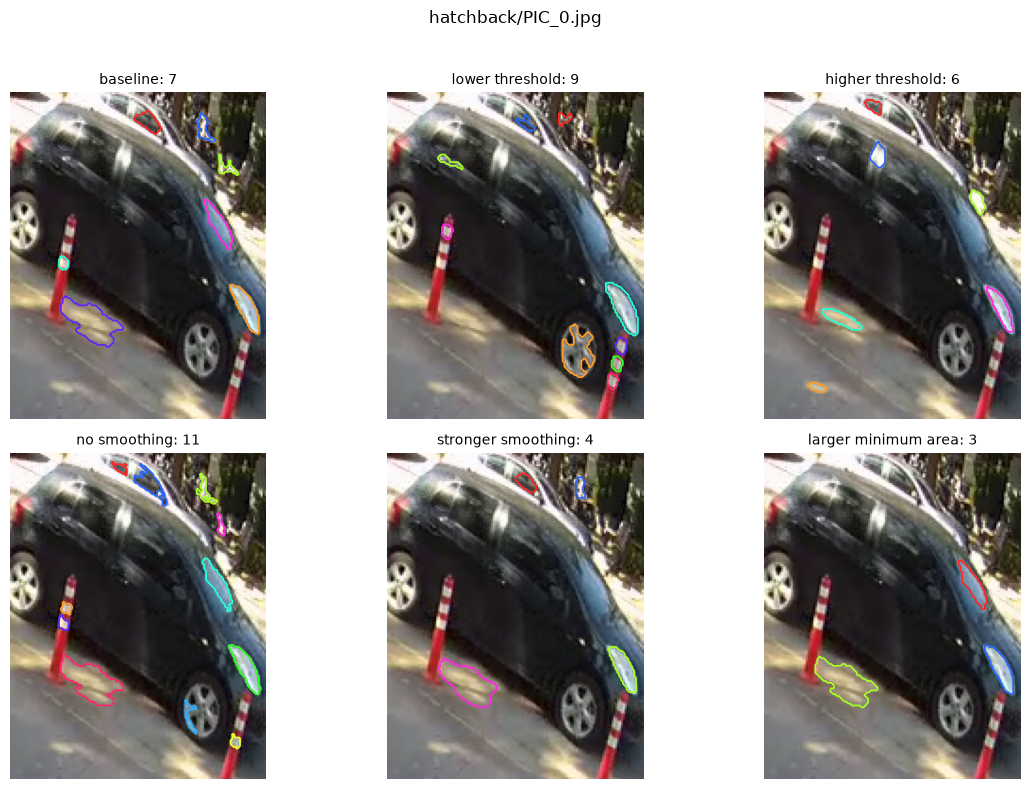

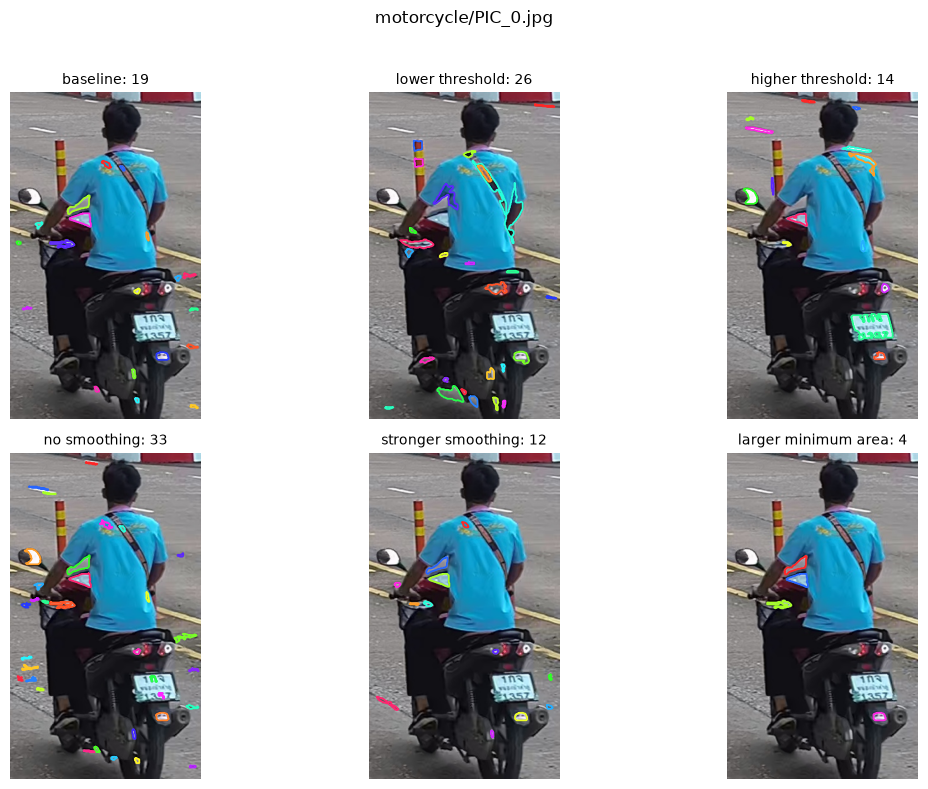

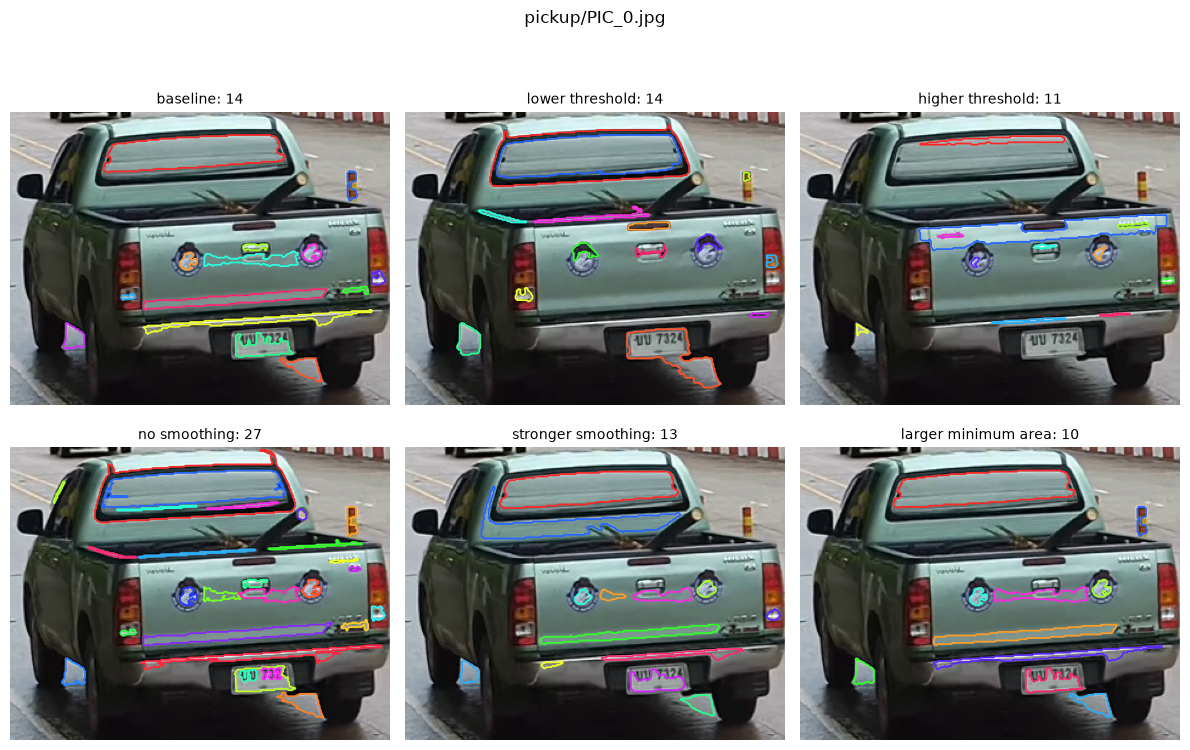

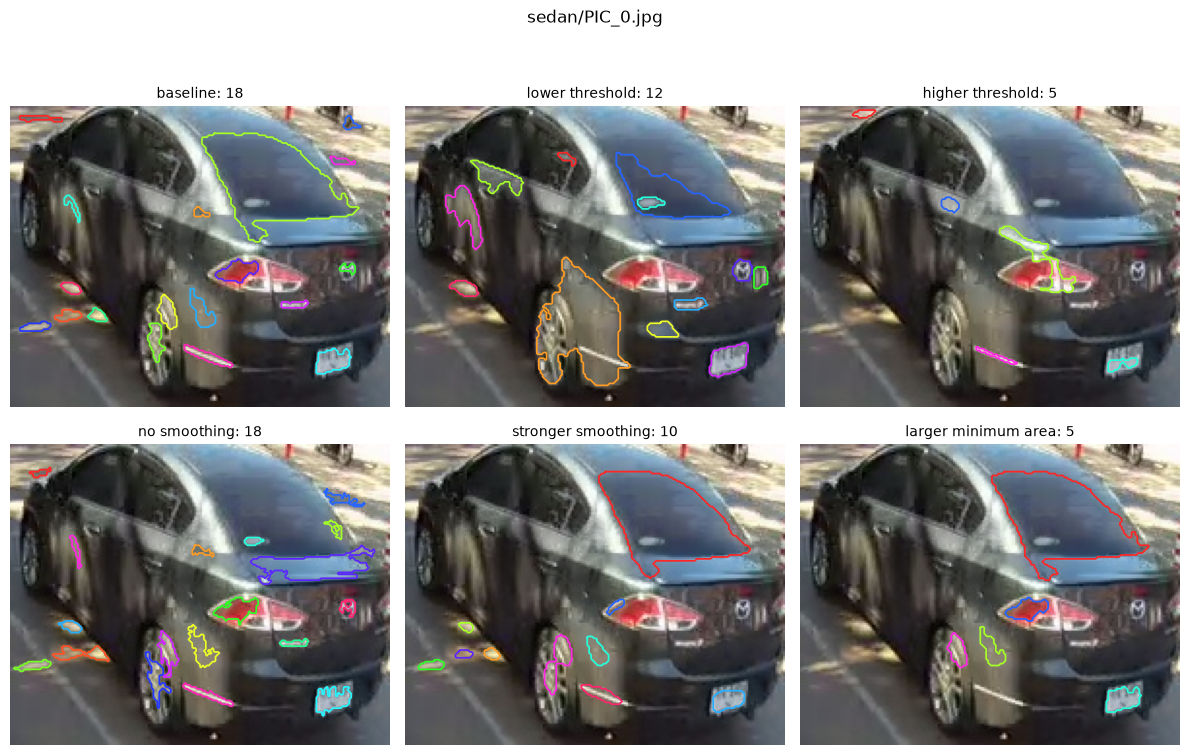

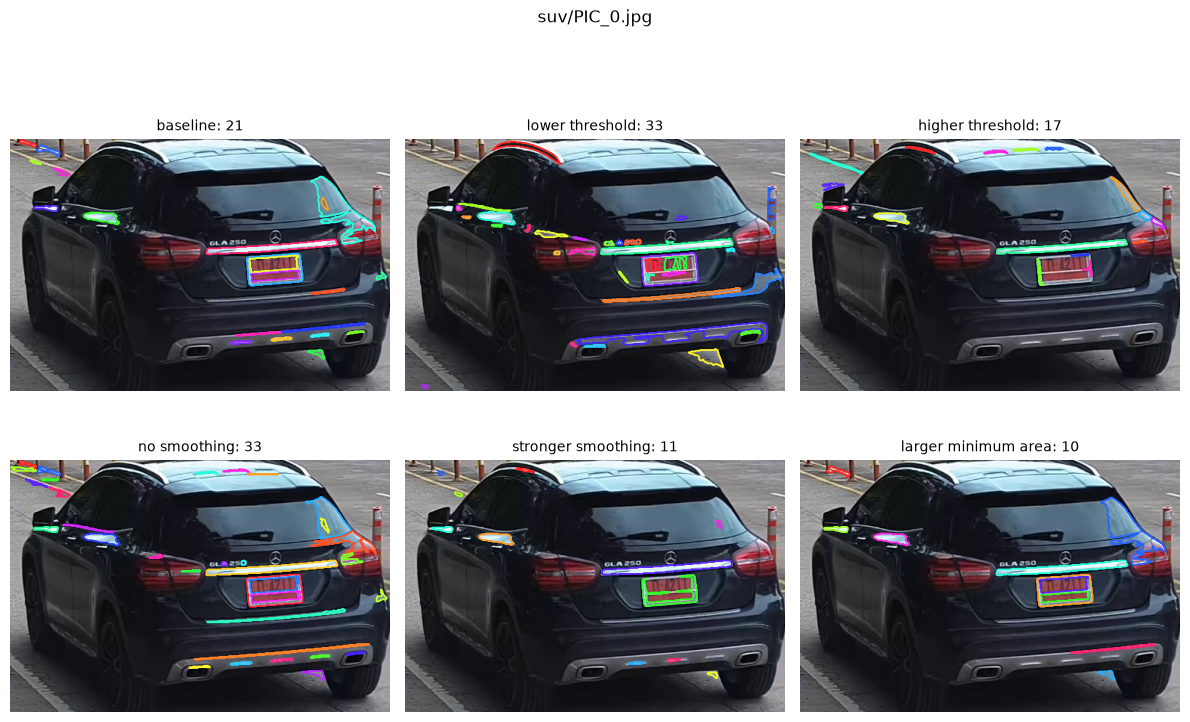

Parameter totals for the fixed sample:
- **baseline**: 158 retained contours; mean loop area 349.7 px²; mean perimeter 95.1 px.
- **lower threshold**: 182 retained contours; mean loop area 343.5 px²; mean perimeter 93.2 px.
- **higher threshold**: 109 retained contours; mean loop area 278.0 px²; mean perimeter 88.7 px.
- **no smoothing**: 230 retained contours; mean loop area 342.6 px²; mean perimeter 101.8 px.
- **stronger smoothing**: 96 retained contours; mean loop area 328.6 px²; mean perimeter 88.1 px.
- **larger minimum area**: 65 retained contours; mean loop area 773.4 px²; mean perimeter 172.1 px.

In [9]:
# One fixed example per class, selected before evaluating results.
classes = list(dict.fromkeys(image_id.split("/")[0] for image_id in image_ids))
example_ids = [next(i for i in image_ids if i.startswith(label + "/")) for label in classes]
for image_id in example_ids:
    fig, axes = plt.subplots(2, 3, figsize=(12, 8))
    for ax, name in zip(axes.flat, CONFIGS):
        result = experiment_results[name][image_id]
        draw_contours(ax, records[image_id], result, f"{name}: {len(result['contours'])}")
    fig.suptitle(image_id)
    fig.tight_layout(rect=(0, 0, 1, 0.96))
    fig.savefig(FIGURE_DIR / ("parameters_" + image_id.replace("/", "_").rsplit(".", 1)[0] + ".png"), dpi=130)
    plt.show()
    plt.close(fig)

lines = ["Parameter totals for the fixed sample:"]
for name, row in aggregate.iterrows():
    lines.append(f"- **{name}**: {int(row.total_contours)} retained contours; "
                 f"mean loop area {row.mean_area_px2:.1f} px²; mean perimeter {row.mean_perimeter_px:.1f} px.")
display(Markdown("\n".join(lines)))

### Interpretation of the measured changes

Lowering the brightness threshold from 0.5 to 0.35 increases retained contours from 158 to 182;
raising it to 0.65 reduces them to 109. For `pickup/PIC_0.jpg`, however, the counts are 14, 14, and 11.
The baseline and lower-threshold panels have the same count but different window, bumper, and plate
boundaries. This demonstrates that contour counts alone hide changes in shape and location.
At the higher threshold, the window region becomes a narrower highlight rather than its broad
baseline shape. Pixel inclusion changes connectivity, so threshold effects need not be monotonic.

Removing smoothing increases retained contours to 230 and increases the mean perimeter from
95.1 to 101.8 pixels. It also produces 1,933 small/degenerate loops that are discarded, compared
with 436 at baseline. In the pickup example, 27 contours replace 14 and the boundaries are visibly
more fragmented and jagged. Smoothing sigma 2 reduces the total to 96, with a mean perimeter of
88.1 pixels. Small details disappear or merge, but changes to region connectivity can also create
new individual loops; the pickup retains 13, not a perfect subset of its 14 baseline contours.

Increasing minimum area from 25 to 100 square pixels leaves the mask and raw paths unchanged,
but reduces retained contours to 65. Mean retained loop area increases from 349.7 to 773.4 square
pixels because the small loops are removed. In the pickup example, counts decrease from 14 to 10
without moving the surviving boundaries. This is a post-detection size filter rather than an
improvement in segmentation.

These settings are illustrative experiments on the same exploratory sample, not a claim of optimal
parameters. The baseline balances visible detail and clutter, but its global threshold is sensitive to
illumination. Different scenes may require improved segmentation or adaptive threshold selection.
Accuracy and a justified optimal setting would require annotated regions and a separate evaluation set.


## 7. Give examples where one technique is more suitable

**Assignment point 7:** Provide examples where blob detection or contour detection may be more suitable.

- **Compact contrast features:** LoG is a useful choice for candidate reflective details, lamp regions,
  or dark patches when their approximate center and scale are sufficient. In the supplied images,
  candidate blobs occur on vehicle details and background features; semantic validation is still needed.
- **Shape measurement:** Closed contours are more suitable when a region is already segmented and
  its irregular outline, area, or perimeter is required. A controlled image of a silhouette against a
  contrasting background is a better setting than cluttered traffic photographs.
- **Whole vehicles in these scenes:** Neither baseline ensures a complete vehicle outline or one
  detection per vehicle. For that goal, improve segmentation or use an annotated semantic detector.
  This assignment comparison concerns image features rather than vehicle recognition.

The comparison illustrates a practical choice: center/scale features for compact regions, boundary
geometry for adequately segmented regions. The supplied scenes also show why the preprocessing and
parameters must be evaluated visually. More detections do not automatically mean better results.

## References and reproducibility (supporting material)

- [ContourPy contour generator](https://contourpy.readthedocs.io/en/v1.3.3/api/contourpy/contour_generator.html): contour-tracing API.
- [ContourPy line formats](https://contourpy.readthedocs.io/en/stable/user_guide/calculate/line_type.html): separate paths with `(x, y)` coordinates.
- [SciPy Gaussian filter](https://docs.scipy.org/doc/scipy/reference/generated/scipy.ndimage.gaussian_filter.html): grayscale smoothing.
- [Blob detection reference](https://scikit-image.org/docs/stable/auto_examples/features_detection/plot_blob.html): LoG scale/radius convention used in the comparison.

The image manifest, parameters, and serial contour engine make this workflow deterministic. Retained
vertices, per-contour measurements, per-image summaries, parameter settings, and comparison tables are
exported. Numerical outputs remain in `results/`; original datasets remain in `data/`.